# Targeted PGD Attacks on CIFAR-10

## Standard vs PGD-$L_\infty$ vs PGD-$L_2$ Trained Models

In this notebook, we study targeted adversarial attacks against the three ResNet-20 models trained previously:

1. Standard model
2. PGD-$L_\infty$ adversarially trained model
3. PGD-$L_2$ adversarially trained model

Unlike untargeted attacks, a targeted attack attempts to force the model toward a specific incorrect class.

We begin with a controlled experiment:

$$
\text{airplane} \rightarrow \text{automobile}.
$$

The attack will be evaluated under both $L_\infty$ and $L_2$ constraints.


In [1]:
RUN_ON_COLAB = False

COLAB_PROJECT_ROOT = "/content/drive/MyDrive/FGSM_PGD"

In [2]:
import sys
from pathlib import Path

if RUN_ON_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")

    PROJECT_ROOT = Path(COLAB_PROJECT_ROOT)

else:
    PROJECT_ROOT = Path.cwd()

    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT = PROJECT_ROOT.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/ali/Desktop/LAB/practical/pgd_robustness_across_norms


In [3]:
DATA_PATH = PROJECT_ROOT / "data"
CHECKPOINTS_PATH = PROJECT_ROOT / "checkpoints"
RESULTS_PATH = PROJECT_ROOT / "results"

DATA_PATH.mkdir(parents=True, exist_ok=True)
CHECKPOINTS_PATH.mkdir(parents=True, exist_ok=True)
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

In [4]:
import torch
import torch.nn.functional as F
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader

from src.data.cifar10 import (
    create_cifar10_datasets,
    create_cifar10_loaders,
)

from src.models.resnet import (
    create_cifar10_resnet20,
)

from src.attacks.pgd import (
    pgd_linf_targeted,
    pgd_l2_targeted,
)

from src.training.engine import (
    evaluate_targeted_adversarial,
)

## 1. Reproducibility

The same CIFAR-10 test set and random seed will be used for all experiments.

All three models will be attacked using the same source images, target class, and attack configuration so that their targeted robustness can be compared directly.


In [5]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [6]:
SEED = 42
set_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cuda'

In [7]:
NUM_CLASSES = 10

BATCH_SIZE = 128
NUM_WORKERS = 2

VAL_SIZE = 5000

## 2. CIFAR-10 Test Data

The targeted attacks are generated directly in pixel space,

$$
x \in [0,1].
$$

Only the CIFAR-10 test set will be used for the experiments in this notebook.

In [8]:
train_dataset, val_dataset, test_dataset = (
    create_cifar10_datasets(
        root=DATA_PATH,
        val_size=VAL_SIZE,
        seed=SEED,
        download=True,
    )
)

_, _, test_loader = create_cifar10_loaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    seed=SEED,
)

print(f"Test samples: {len(test_dataset)}")

Test samples: 10000


## 3. Load Trained Models

We load the best checkpoints obtained from the previous notebook:

1. Standard ResNet-20
2. PGD-$L_\infty$ adversarially trained ResNet-20
3. PGD-$L_2$ adversarially trained ResNet-20

The same model architecture is used for all three checkpoints.


In [9]:
standard_checkpoint_path = (
    CHECKPOINTS_PATH
    / "resnet20_cifar10_standard_best.pt"
)

linf_checkpoint_path = (
    CHECKPOINTS_PATH
    / "resnet20_cifar10_pgd_linf_best.pt"
)

l2_checkpoint_path = (
    CHECKPOINTS_PATH
    / "resnet20_cifar10_pgd_l2_best.pt"
)

standard_model = create_cifar10_resnet20(
    num_classes=NUM_CLASSES,
).to(device)

linf_model = create_cifar10_resnet20(
    num_classes=NUM_CLASSES,
).to(device)

l2_model = create_cifar10_resnet20(
    num_classes=NUM_CLASSES,
).to(device)

standard_checkpoint = torch.load(
    standard_checkpoint_path,
    map_location=device,
)

linf_checkpoint = torch.load(
    linf_checkpoint_path,
    map_location=device,
)

l2_checkpoint = torch.load(
    l2_checkpoint_path,
    map_location=device,
)


standard_model.load_state_dict(
    standard_checkpoint["model_state_dict"]
)

linf_model.load_state_dict(
    linf_checkpoint["model_state_dict"]
)

l2_model.load_state_dict(
    l2_checkpoint["model_state_dict"]
)


standard_model.eval()
linf_model.eval()
l2_model.eval()

CIFAR10ResNet20(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05,

In [10]:
# Sanity Check

images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():

    standard_logits = standard_model(images)
    linf_logits = linf_model(images)
    l2_logits = l2_model(images)


print(
    "Standard output shape:",
    standard_logits.shape
)

print(
    "PGD-Linf output shape:",
    linf_logits.shape
)

print(
    "PGD-L2 output shape:",
    l2_logits.shape
)

Standard output shape: torch.Size([128, 10])
PGD-Linf output shape: torch.Size([128, 10])
PGD-L2 output shape: torch.Size([128, 10])


In [11]:
# Sanity Check

standard_acc = (
    standard_logits.argmax(dim=1) == labels
).float().mean().item()

linf_acc = (
    linf_logits.argmax(dim=1) == labels
).float().mean().item()

l2_acc = (
    l2_logits.argmax(dim=1) == labels
).float().mean().item()


print(
    f"Standard batch accuracy: {100 * standard_acc:.2f}%"
)

print(
    f"PGD-Linf batch accuracy: {100 * linf_acc:.2f}%"
)

print(
    f"PGD-L2 batch accuracy: {100 * l2_acc:.2f}%"
)

Standard batch accuracy: 92.97%
PGD-Linf batch accuracy: 75.78%
PGD-L2 batch accuracy: 83.59%


## 4. Targeted Attack Setup

We begin with a single targeted attack:

$$
\text{airplane} \rightarrow \text{automobile}.
$$

To compare the three models fairly, we attack only test images that:

1. belong to the source class `airplane`, and
2. are correctly classified as `airplane` by all three models before the attack.

In [12]:
SOURCE_CLASS = 0
TARGET_CLASS = 1

SOURCE_NAME = "airplane"
TARGET_NAME = "automobile"

# Targeted PGD-Linf
LINF_EPSILON = 32 / 255
LINF_STEP_SIZE = 2 / 255
LINF_STEPS = 40

# Targeted PGD-L2
L2_EPSILON = 4.0
L2_STEP_SIZE = 0.2
L2_STEPS = 40

RANDOM_START = True

##  5. Select Eligible Source Images

Targeted attack success should be measured only on examples that are correctly classified before the attack.

We additionally require all three models to classify the source image correctly, so that their attack success rates are evaluated on exactly the same set of images.


In [13]:
eligible_images = []
eligible_labels = []

standard_model.eval()
linf_model.eval()
l2_model.eval()


for images, labels in test_loader:

    images = images.to(device)
    labels = labels.to(device)

    source_mask = labels == SOURCE_CLASS

    if source_mask.sum() == 0:
        continue

    source_images = images[source_mask]
    source_labels = labels[source_mask]

    with torch.no_grad():

        standard_predictions = (
            standard_model(source_images)
            .argmax(dim=1)
        )

        linf_predictions = (
            linf_model(source_images)
            .argmax(dim=1)
        )

        l2_predictions = (
            l2_model(source_images)
            .argmax(dim=1)
        )

    correct_mask = (
        (standard_predictions == SOURCE_CLASS)
        & (linf_predictions == SOURCE_CLASS)
        & (l2_predictions == SOURCE_CLASS)
    )

    if correct_mask.any():

        eligible_images.append(
            source_images[correct_mask].cpu()
        )

        eligible_labels.append(
            source_labels[correct_mask].cpu()
        )


eligible_images = torch.cat(
    eligible_images,
    dim=0
)

eligible_labels = torch.cat(
    eligible_labels,
    dim=0
)


print(
    f"Eligible {SOURCE_NAME} images:",
    len(eligible_images)
)

Eligible airplane images: 756


## 6. Targeted PGD-$L_\infty$ Evaluation

We first evaluate the targeted PGD attack under an $L_\infty$ constraint.

The attack budget is

$$
\epsilon = \frac{32}{255}.
$$

For each model, the attack attempts to transform correctly classified `airplane` images into the target prediction `automobile`.

The main metric is the **Targeted Attack Success Rate (TASR)**:

$$
\mathrm{TASR}
=
\frac{
\#\{f(x_{\mathrm{adv}})=y_{\mathrm{target}}\}
}{
\#\{\mathrm{eligible\ source\ images}\}
}.
$$


In [14]:
eligible_dataset = TensorDataset(
    eligible_images,
    eligible_labels
)

eligible_loader = DataLoader(
    eligible_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

In [15]:
targeted_linf_attack_kwargs = {
    "epsilon": LINF_EPSILON,
    "step_size": LINF_STEP_SIZE,
    "steps": LINF_STEPS,
    "random_start": RANDOM_START
}

targeted_l2_attack_kwargs = {
    "epsilon": L2_EPSILON,
    "step_size": L2_STEP_SIZE,
    "steps": L2_STEPS,
    "random_start": RANDOM_START
}

In [16]:
set_seed(SEED)

standard_linf_result = evaluate_targeted_adversarial(
    model=standard_model,
    loader=eligible_loader,
    device=device,
    attack_fn=pgd_linf_targeted,
    attack_kwargs=targeted_linf_attack_kwargs,
    target_class=TARGET_CLASS,
)


set_seed(SEED)

linf_trained_linf_result = evaluate_targeted_adversarial(
    model=linf_model,
    loader=eligible_loader,
    device=device,
    attack_fn=pgd_linf_targeted,
    attack_kwargs=targeted_linf_attack_kwargs,
    target_class=TARGET_CLASS,
)


set_seed(SEED)

l2_trained_linf_result = evaluate_targeted_adversarial(
    model=l2_model,
    loader=eligible_loader,
    device=device,
    attack_fn=pgd_linf_targeted,
    attack_kwargs=targeted_linf_attack_kwargs,
    target_class=TARGET_CLASS,
)

In [17]:
print(
    "Standard:",
    f"{100 * standard_linf_result['success_rate']:.2f}%"
)

print(
    "PGD-Linf Trained:",
    f"{100 * linf_trained_linf_result['success_rate']:.2f}%"
)

print(
    "PGD-L2 Trained:",
    f"{100 * l2_trained_linf_result['success_rate']:.2f}%"
)

Standard: 100.00%
PGD-Linf Trained: 89.68%
PGD-L2 Trained: 99.60%


## 7. Visualizing Successful Targeted PGD-$L_\infty$ Attacks

In [18]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

In [19]:
def find_one_successful_targeted_example(
    model,
    images,
    source_class,
    target_class,
    attack_fn,
    attack_kwargs,
    batch_size=128,
):
    model.eval()

    for start in range(0, len(images), batch_size):
        end = start + batch_size

        batch_images = images[start:end].to(device)

        with torch.no_grad():
            clean_logits = model(batch_images)
            clean_predictions = clean_logits.argmax(dim=1)

        target_labels = torch.full(
            (batch_images.size(0),),
            target_class,
            device=device,
            dtype=torch.long,
        )

        x_adv = attack_fn(
            model=model,
            images=batch_images,
            target_labels=target_labels,
            **attack_kwargs,
        )

        with torch.no_grad():
            adv_logits = model(x_adv)
            adv_predictions = adv_logits.argmax(dim=1)

        success_mask = (
            (clean_predictions == source_class)
            & (adv_predictions == target_class)
        )

        if success_mask.any():
            idx = success_mask.nonzero(as_tuple=False)[0].item()

            clean_image = batch_images[idx].detach().cpu()
            adv_image = x_adv[idx].detach().cpu()
            delta = (adv_image - clean_image).detach().cpu()

            clean_pred = clean_predictions[idx].item()
            adv_pred = adv_predictions[idx].item()

            return {
                "clean_image": clean_image,
                "adv_image": adv_image,
                "delta": delta,
                "clean_pred": clean_pred,
                "adv_pred": adv_pred,
            }

    return None

In [20]:
def show_targeted_example(example, model_name):
    clean_image = example["clean_image"]
    adv_image = example["adv_image"]
    delta = example["delta"]

    delta_linf = delta.abs().max().item()

    delta_min = delta.min()
    delta_max = delta.max()

    delta_vis = (delta - delta_min) / (delta_max - delta_min + 1e-8)

    clean_np = clean_image.permute(1, 2, 0).numpy()
    adv_np = adv_image.permute(1, 2, 0).numpy()
    delta_np = delta_vis.permute(1, 2, 0).numpy()

    fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

    axes[0].imshow(clean_np)
    axes[0].set_title(
        f"Original\nPred: {class_names[example['clean_pred']]}"
    )
    axes[0].axis("off")

    axes[1].imshow(delta_np)
    axes[1].set_title(
        f"Perturbation\n(rescaled)\n||δ||∞ = {delta_linf:.4f}"
    )
    axes[1].axis("off")

    axes[2].imshow(adv_np)
    axes[2].set_title(
        f"Adversarial\nPred: {class_names[example['adv_pred']]}"
    )
    axes[2].axis("off")

    fig.suptitle(
        f"{model_name} | {SOURCE_NAME} → {TARGET_NAME}",
        fontsize=12,
    )

    plt.tight_layout()
    plt.show()

In [21]:
set_seed(SEED)

standard_success_example = find_one_successful_targeted_example(
    model=standard_model,
    images=eligible_images,
    source_class=SOURCE_CLASS,
    target_class=TARGET_CLASS,
    attack_fn=pgd_linf_targeted,
    attack_kwargs=targeted_linf_attack_kwargs,
)

set_seed(SEED)

linf_success_example = find_one_successful_targeted_example(
    model=linf_model,
    images=eligible_images,
    source_class=SOURCE_CLASS,
    target_class=TARGET_CLASS,
    attack_fn=pgd_linf_targeted,
    attack_kwargs=targeted_linf_attack_kwargs,
)

set_seed(SEED)

l2_success_example = find_one_successful_targeted_example(
    model=l2_model,
    images=eligible_images,
    source_class=SOURCE_CLASS,
    target_class=TARGET_CLASS,
    attack_fn=pgd_linf_targeted,
    attack_kwargs=targeted_linf_attack_kwargs,
)

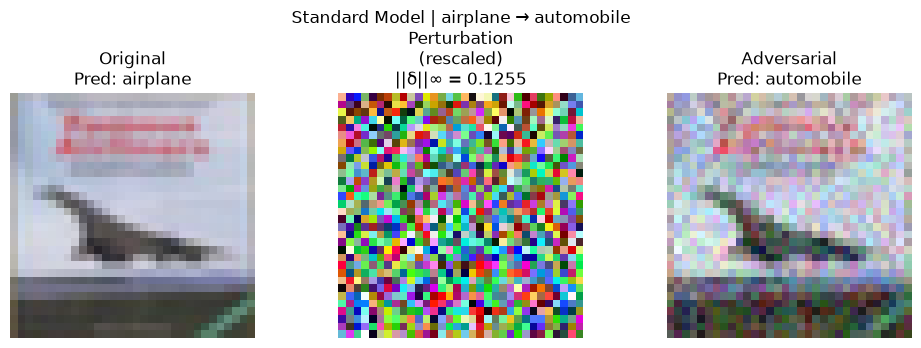

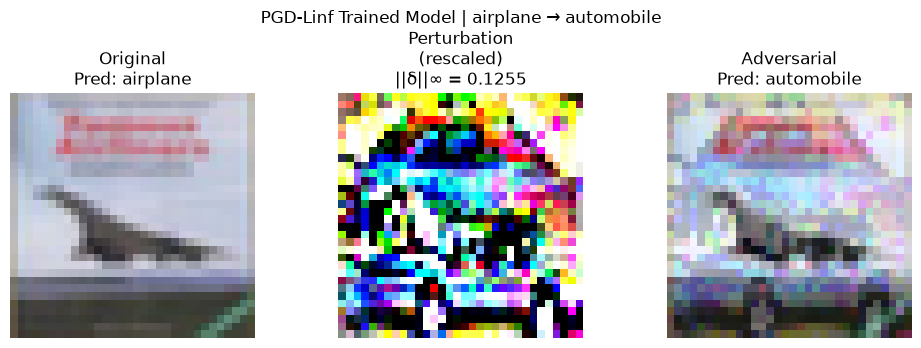

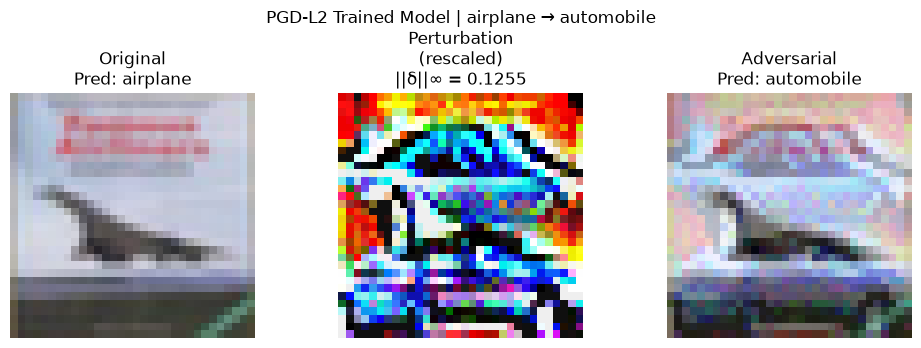

In [22]:
show_targeted_example(
    standard_success_example,
    "Standard Model"
)

show_targeted_example(
    linf_success_example,
    "PGD-Linf Trained Model"
)

show_targeted_example(
    l2_success_example,
    "PGD-L2 Trained Model"
)

## 8. Targeted PGD-$L_2$ Evaluation

We now evaluate the same targeted attack under an $L_2$ constraint.

The attack budget is

$$
\epsilon = 4.
$$

As before, the attack attempts to transform correctly classified `airplane` images into the target prediction `automobile`.

The same eligible source images are used for all three models so that the targeted attack success rates remain directly comparable.


In [23]:
set_seed(SEED)

standard_l2_result = evaluate_targeted_adversarial(
    model=standard_model,
    loader=eligible_loader,
    device=device,
    attack_fn=pgd_l2_targeted,
    attack_kwargs=targeted_l2_attack_kwargs,
    target_class=TARGET_CLASS,
)


set_seed(SEED)

linf_trained_l2_result = evaluate_targeted_adversarial(
    model=linf_model,
    loader=eligible_loader,
    device=device,
    attack_fn=pgd_l2_targeted,
    attack_kwargs=targeted_l2_attack_kwargs,
    target_class=TARGET_CLASS,
)


set_seed(SEED)

l2_trained_l2_result = evaluate_targeted_adversarial(
    model=l2_model,
    loader=eligible_loader,
    device=device,
    attack_fn=pgd_l2_targeted,
    attack_kwargs=targeted_l2_attack_kwargs,
    target_class=TARGET_CLASS,
)

In [24]:
print(
    "Standard:",
    f"{100 * standard_l2_result['success_rate']:.2f}%"
)

print(
    "PGD-Linf Trained:",
    f"{100 * linf_trained_l2_result['success_rate']:.2f}%"
)

print(
    "PGD-L2 Trained:",
    f"{100 * l2_trained_l2_result['success_rate']:.2f}%"
)

Standard: 100.00%
PGD-Linf Trained: 98.41%
PGD-L2 Trained: 99.21%


## 9. Visualizing Successful Targeted PGD-$L_2$ Attacks

In [25]:
def show_targeted_l2_example(example, model_name):
    clean_image = example["clean_image"]
    adv_image = example["adv_image"]
    delta = example["delta"]

    delta_l2 = torch.linalg.vector_norm(
        delta.flatten(),
        ord=2,
    ).item()

    delta_min = delta.min()
    delta_max = delta.max()

    delta_vis = (
        (delta - delta_min)
        / (delta_max - delta_min + 1e-8)
    )

    clean_np = clean_image.permute(1, 2, 0).numpy()
    adv_np = adv_image.permute(1, 2, 0).numpy()
    delta_np = delta_vis.permute(1, 2, 0).numpy()

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(10, 3.5),
    )

    axes[0].imshow(clean_np)
    axes[0].set_title(
        f"Original\nPred: "
        f"{class_names[example['clean_pred']]}"
    )
    axes[0].axis("off")

    axes[1].imshow(delta_np)
    axes[1].set_title(
        f"Perturbation\n"
        f"(rescaled)\n"
        f"||δ||₂ = {delta_l2:.4f}"
    )
    axes[1].axis("off")

    axes[2].imshow(adv_np)
    axes[2].set_title(
        f"Adversarial\nPred: "
        f"{class_names[example['adv_pred']]}"
    )
    axes[2].axis("off")

    fig.suptitle(
        f"{model_name} | "
        f"{SOURCE_NAME} → {TARGET_NAME}",
        fontsize=12,
    )

    plt.tight_layout()
    plt.show()

In [26]:
set_seed(SEED)

standard_l2_success_example = find_one_successful_targeted_example(
    model=standard_model,
    images=eligible_images,
    source_class=SOURCE_CLASS,
    target_class=TARGET_CLASS,
    attack_fn=pgd_l2_targeted,
    attack_kwargs=targeted_l2_attack_kwargs,
)


set_seed(SEED)

linf_l2_success_example = find_one_successful_targeted_example(
    model=linf_model,
    images=eligible_images,
    source_class=SOURCE_CLASS,
    target_class=TARGET_CLASS,
    attack_fn=pgd_l2_targeted,
    attack_kwargs=targeted_l2_attack_kwargs,
)


set_seed(SEED)

l2_l2_success_example = find_one_successful_targeted_example(
    model=l2_model,
    images=eligible_images,
    source_class=SOURCE_CLASS,
    target_class=TARGET_CLASS,
    attack_fn=pgd_l2_targeted,
    attack_kwargs=targeted_l2_attack_kwargs,
)

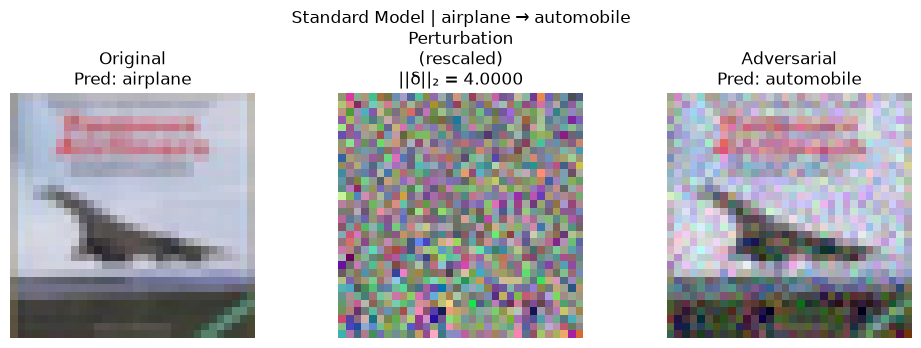

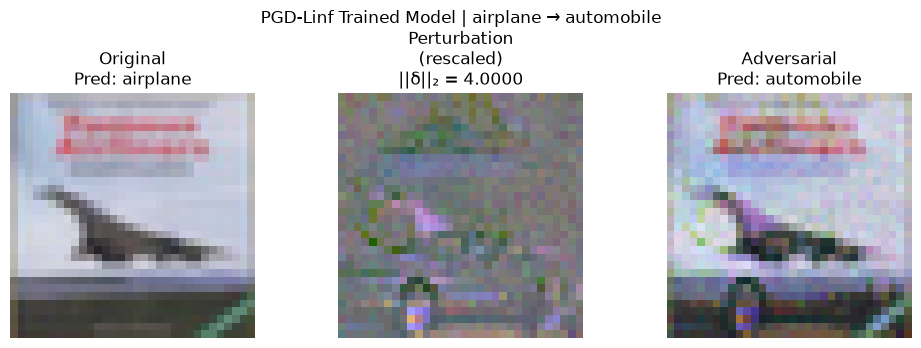

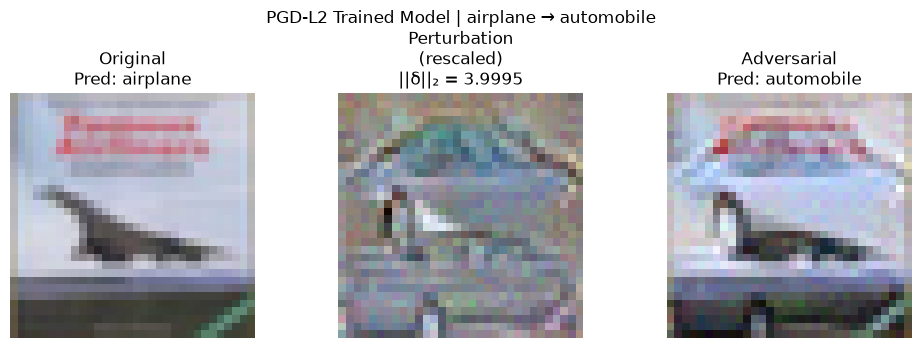

In [27]:
show_targeted_l2_example(
    standard_l2_success_example,
    "Standard Model",
)

show_targeted_l2_example(
    linf_l2_success_example,
    "PGD-Linf Trained Model",
)

show_targeted_l2_example(
    l2_l2_success_example,
    "PGD-L2 Trained Model",
)

## 10. Targeted Attack Results

The following table summarizes the Targeted Attack Success Rate (TASR)
for the three models under both $L_\infty$ and $L_2$ targeted PGD attacks.

The source-target pair is:

$$
\text{airplane} \rightarrow \text{automobile}
$$

In [29]:
targeted_results_df = pd.DataFrame(
    [
        {
            "Model": "Standard",
            "PGD-Linf TASR (%)":
                100 * standard_linf_result["success_rate"],
            "PGD-L2 TASR (%)":
                100 * standard_l2_result["success_rate"],
        },
        {
            "Model": "PGD-Linf Trained",
            "PGD-Linf TASR (%)":
                100 * linf_trained_linf_result["success_rate"],
            "PGD-L2 TASR (%)":
                100 * linf_trained_l2_result["success_rate"],
        },
        {
            "Model": "PGD-L2 Trained",
            "PGD-Linf TASR (%)":
                100 * l2_trained_linf_result["success_rate"],
            "PGD-L2 TASR (%)":
                100 * l2_trained_l2_result["success_rate"],
        },
    ]
)


targeted_results_df.style.format(
    {
        "PGD-Linf TASR (%)": "{:.2f}",
        "PGD-L2 TASR (%)": "{:.2f}",
    }
)

,Model,PGD-Linf TASR (%),PGD-L2 TASR (%)
0,Standard,100.00,100.00
1,PGD-Linf Trained,89.68,98.41
2,PGD-L2 Trained,99.60,99.21
